In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# 장치 설정 (GPU가 있으면 사용, 없으면 CPU fallback)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 데이터 불러오기 (사용자 로컬 경로로 수정 필요)
df = pd.read_csv("./_VEHICLE_ING_INFO_.csv")
df1 = df[(df["V_TIMESTAMP"] > "2025-05-29 00:00:00") &(df["V_TIMESTAMP"] < "2025-05-30 00:00:00")]

df1.dropna(axis=1, inplace=True)
df1.drop(columns=["VEHICLE_ID","VEHICLE_TYPE","V_TIMESTAMP","REGIST_DATE"], inplace=True)
df1 = df1[df1["SPEED"] > 0]
df1

# 사용할 feature 및 target
features = ['WHEEL_SPEED', 'YAW_RATE']
target = 'SPEED'

# 전처리
data = df1[features + [target]].dropna()
X = data[features].values
y = data[target].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 데이터셋 분할
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 텐서 변환 및 GPU 이동
X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1).to(device)
X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1, 1).to(device)

# 고급 회귀 모델 정의
class AdvancedSpeedPredictor(nn.Module):
    def __init__(self):
        super(AdvancedSpeedPredictor, self).__init__()
        self.fc1 = nn.Linear(len(features), 64)
        self.bn1 = nn.BatchNorm1d(64)
        self.dropout1 = nn.Dropout(0.3)

        self.fc2 = nn.Linear(64, 128)
        self.bn2 = nn.BatchNorm1d(128)
        self.dropout2 = nn.Dropout(0.3)

        self.fc3 = nn.Linear(128, 64)
        self.bn3 = nn.BatchNorm1d(64)
        self.dropout3 = nn.Dropout(0.3)

        self.output = nn.Linear(64, 1)

    def forward(self, x):
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.dropout1(x)
        x = F.relu(self.bn2(self.fc2(x)))
        x = self.dropout2(x)
        x = F.relu(self.bn3(self.fc3(x)))
        x = self.dropout3(x)
        return self.output(x)

# 모델, 손실함수, 옵티마이저 초기화
model = AdvancedSpeedPredictor().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)

# 학습 루프
epochs = 100
for epoch in range(epochs):
    model.train()
    preds = model(X_train)
    loss = criterion(preds, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f"[{epoch+1}/{epochs}] Train Loss: {loss.item():.4f}")

# 테스트 평가
model.eval()
with torch.no_grad():
    preds_test = model(X_test)
    # preds_test = pree
    test_loss = criterion(preds_test, y_test)
    print(f"Test Loss (MSE): {test_loss.item():.4f}")



In [ ]:
df = pd.read_csv("./_VEHICLE_ING_INFO_.csv")

features = ['MDPS_ANGLE', 'DRIVING_DISTANCE', 'WHEEL_SPEED', 'AUTO_DRIVING_STATUS',
            'TURN_SIGNAL', 'YAW_RATE', 'HEADING', 'GEAR_STATUS', 'BRAKE_STATUS', 'BRAKE', 'ACCEL']
target = 'SPEED'

# 장치 설정 (GPU가 있으면 사용, 없으면 CPU fallback)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

data = df[features + [target]].dropna()
x = data[features].values
y = data[target].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(x)

# 데이터셋 분할
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 텐서 변환 및 GPU 이동
X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1).to(device)
X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1, 1).to(device)

# 모델 재정의 및 로드
model = AdvancedSpeedPredictor().to(device)
#model.load_state_dict(torch.load("speed_predictor.pth"))

# 모델 평가
model.eval()
with torch.no_grad():
    preds_test = model(X_test)
    test_loss = criterion(preds_test, y_test)
    print(f"Test Loss (MSE): {test_loss.item():.4f}")

# 예측 결과 시각화
import matplotlib.pyplot as plt
plt.figure(figsize=(18, 6))
plt.plot(y_test.cpu().numpy(), label='Actual Speed', alpha=0.1)
plt.plot(preds_test.cpu().numpy(), label='Predicted Speed', alpha=0.7)
plt.title('Actual vs Predicted Speed')
plt.xlabel('Sample Index')
plt.ylabel('Speed (m/s)')
plt.legend()
plt.show()

#예측 결과 저장
predictions_df = pd.DataFrame({
    'Actual Speed': y_test.cpu().numpy().flatten(),
    'Predicted Speed': preds_test.cpu().numpy().flatten()
})

predictions_df.to_csv(".speed_predictions.csv", index=False)
# 예측 결과 출력
print(predictions_df.head())


In [ ]:
df1 = df[(df["V_TIMESTAMP"] > "2025-05-29 00:00:00") &(df["V_TIMESTAMP"] < "2025-05-30 00:00:00")]

df1.dropna(axis=1, inplace=True)
df1.drop(columns=["VEHICLE_ID","VEHICLE_TYPE","V_TIMESTAMP","REGIST_DATE"], inplace=True)
df1 = df1[df1["SPEED"] > 0]
df1

In [ ]:
df1 = df[(df["V_TIMESTAMP"] > "2025-05-29 00:00:00") &(df["V_TIMESTAMP"] < "2025-05-30 00:00:00")]

df1.dropna(axis=1, inplace=True)
df1.drop(columns=["VEHICLE_ID","VEHICLE_TYPE","V_TIMESTAMP","REGIST_DATE"], inplace=True)
df1 = df1[df1["SPEED"] > 0]
df1


features = ['WHEEL_SPEED', 'BRAKE', 'BRAKE_STATUS', 'YAW_RATE']
target = 'SPEED'

# 장치 설정 (GPU가 있으면 사용, 없으면 CPU fallback)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

data = df1[features + [target]].dropna()
x = data[features].values
y = data[target].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(x)

# 데이터셋 분할
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 텐서 변환 및 GPU 이동
X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1).to(device)
X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1, 1).to(device)

# 모델 재정의 및 로드
model = AdvancedSpeedPredictor().to(device)
#model.load_state_dict(torch.load("speed_predictor.pth"))

# 모델 평가
model.eval()
with torch.no_grad():
    preds_test = model(X_test)
    test_loss = criterion(preds_test, y_test)
    print(f"Test Loss (MSE): {test_loss.item():.4f}")

# 예측 결과 시각화
import matplotlib.pyplot as plt
plt.figure(figsize=(18, 6))
plt.plot(y_test.cpu().numpy(), label='Actual Speed', alpha=0.1)
plt.plot(preds_test.cpu().numpy(), label='Predicted Speed', alpha=0.7)
plt.title('한글이 안나오나?Actual vs Predicted Speed')
plt.xlabel('Sample Index')
plt.ylabel('Speed (m/s)')
plt.legend()
plt.show()

#예측 결과 저장
predictions_df = pd.DataFrame({
    'Actual Speed': y_test.cpu().numpy().flatten(),
    'Predicted Speed': preds_test.cpu().numpy().flatten()
})

predictions_df.to_csv(".speed_predictions.csv", index=False)
# 예측 결과 출력
print(predictions_df.head())

In [ ]:
features = ['MDPS_ANGLE', 'DRIVING_DISTANCE', 'WHEEL_SPEED', 'AUTO_DRIVING_STATUS',
            'TURN_SIGNAL', 'YAW_RATE', 'HEADING', 'GEAR_STATUS', 'BRAKE_STATUS', 'BRAKE', 'ACCEL']
target = 'SPEED'
df1

df1 = df[(df["V_TIMESTAMP"] > "2025-05-29 00:00:00") &(df["V_TIMESTAMP"] < "2025-05-30 00:00:00")]

df1.dropna(axis=1, inplace=True)
df1.drop(columns=["VEHICLE_ID","VEHICLE_TYPE","V_TIMESTAMP","REGIST_DATE"], inplace=True)
df1 = df1[df1["SPEED"] > 0]
df1

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 상관관계 히트맵 시각화
corr_matrix = df1[features + [target]].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8}, linecolor='white', linewidths=0.1)
plt.xticks(rotation=45)
plt.title('Correlation Feature with Speed')
plt.show()
# 상관관계 분석 결과 출력
print("Correlation Analysis:")
print(corr_matrix[target].sort_values(ascending=False))

In [ ]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

# RFE를 사용한 특성 선택

X = df1[features].dropna()
y = df1.loc[X.index, 'SPEED']
model = LinearRegression()
selector = RFE(model, n_features_to_select=5)
selector = selector.fit(X, y)
selected_features = X.columns[selector.support_]
print("Selected Features using RFE:")
print(selected_features.tolist())
# 특성 중요도 시각화
import matplotlib.pyplot as plt
importances = selector.estimator_.coef_
plt.figure(figsize=(10, 6))
plt.barh(selected_features, importances)
plt.xlabel('Feature Importance')
plt.title('Feature Importance from RFE')
plt.show()
# 특성 중요도 출력
print("Feature Importances:")
for feature, importance in zip(selected_features, importances):
    print(f"{feature}: {importance:.4f}")


In [ ]:
rc = pd.read_csv("./_VEHICLE_ING_INFO_TRAC.csv")

In [ ]:
rc
# 상관관계 히트맵 시각화
plt.figure(figsize=(12, 8))
sns.heatmap(rc, annot=True, fmt=".3f", cmap='coolwarm', square=True, cbar_kws={"shrink": .99}, linecolor='white', linewidths=0.5)
plt.xticks(rotation=45)
plt.title('Correlation Feature with Speed')
plt.show()
# 상관관계 분석 결과 출력
print("Correlation Analysis:")
print(rc[target].sort_values(ascending=False))
# 특성 중요도 시각화
importances = rc[target].sort_values(ascending=False)
plt.figure(figsize=(10, 6))
plt.barh(importances.index, importances.values)
plt.xlabel('Correlation Coefficient')
plt.title('Feature Correlation with Speed')
plt.show()
# 특성 중요도 출력
print("Feature Correlations with Speed:")
for feature, importance in importances.items():
    print(f"{feature}: {importance:.4f}")

In [ ]:
rc = pd.read_csv("./_VEHICLE_ING_INFO_TRAC.csv")

features = ['MDPS_ANGLE', 'WHEEL_SPEED', 'YAW_RATE', 'HEADING', 'BRAKE_STATUS', 'BRAKE', 'ACCEL']
target = 'SPEED'
rc[features + [target]]

rc['WHEEL_SPEED']


In [ ]:

# 장치 설정 (GPU가 있으면 사용, 없으면 CPU fallback)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

data = rc[features + [target]]
x = data[features].values
y = data[target].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(x)

# 데이터셋 분할
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 텐서 변환 및 GPU 이동
X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1).to(device)
X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1, 1).to(device)

# 모델 재정의 및 로드
model = AdvancedSpeedPredictor().to(device)
#model.load_state_dict(torch.load("speed_predictor.pth"))

# 모델 평가
model.eval()
with torch.no_grad():
    preds_test = model(X_test)
    test_loss = criterion(preds_test, y_test)
    print(f"Test Loss (MSE): {test_loss.item():.4f}")

# 예측 결과 시각화
import matplotlib.pyplot as plt
plt.figure(figsize=(18, 6))
plt.plot(y_test.cpu().numpy(), label='Actual Speed', alpha=0.1)
plt.plot(preds_test.cpu().numpy(), label='Predicted Speed', alpha=0.7)
plt.title('Actual vs Predicted Speed')
plt.xlabel('Sample Index')
plt.ylabel('Speed (m/s)')
plt.legend()
plt.show()

#예측 결과 저장
predictions_df = pd.DataFrame({
    'Actual Speed': y_test.cpu().numpy().flatten(),
    'Predicted Speed': preds_test.cpu().numpy().flatten()
})

predictions_df.to_csv(".speed_predictions.csv", index=False)
# 예측 결과 출력
print(predictions_df.head())

In [3]:
import matplotlib.font_manager as fm

nanum_font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(nanum_font_path)
plt.rcParams['font.family'] = fm.FontProperties(fname=nanum_font_path).get_name()
plt.rcParams['font.family']

['NanumGothic']

0. 실제 데이터 로드 및 기본 전처리 중...
원본 데이터 샘플:
   I_INDEX  VEHICLE_ID VEHICLE_TYPE   LATITUDE   LONGITUDE  SPEED  \
0    14740  TRAC000001            T  36.466375  127.075636   0.03   
1    14741  TRAC000001            T  36.466375  127.075636   0.03   
2    14742  TRAC000001            T  36.466375  127.075636   0.04   
3    14743  TRAC000001            T  36.466375  127.075636   0.08   
4    14744  TRAC000001            T  36.466375  127.075636   0.05   

   AUTO_DRIVING_STATUS       V_TIMESTAMP  HEADING  GEAR_STATUS  BRAKE_STATUS  
0                    0  2025-05-22 14:42    93.66            0             0  
1                    0  2025-05-22 14:42    93.66            0             0  
2                    0  2025-05-22 14:42    93.65            0             0  
3                    0  2025-05-22 14:42    93.65            0             0  
4                    0  2025-05-22 14:42    93.66            0             0  

데이터 정보:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1687 entries, 

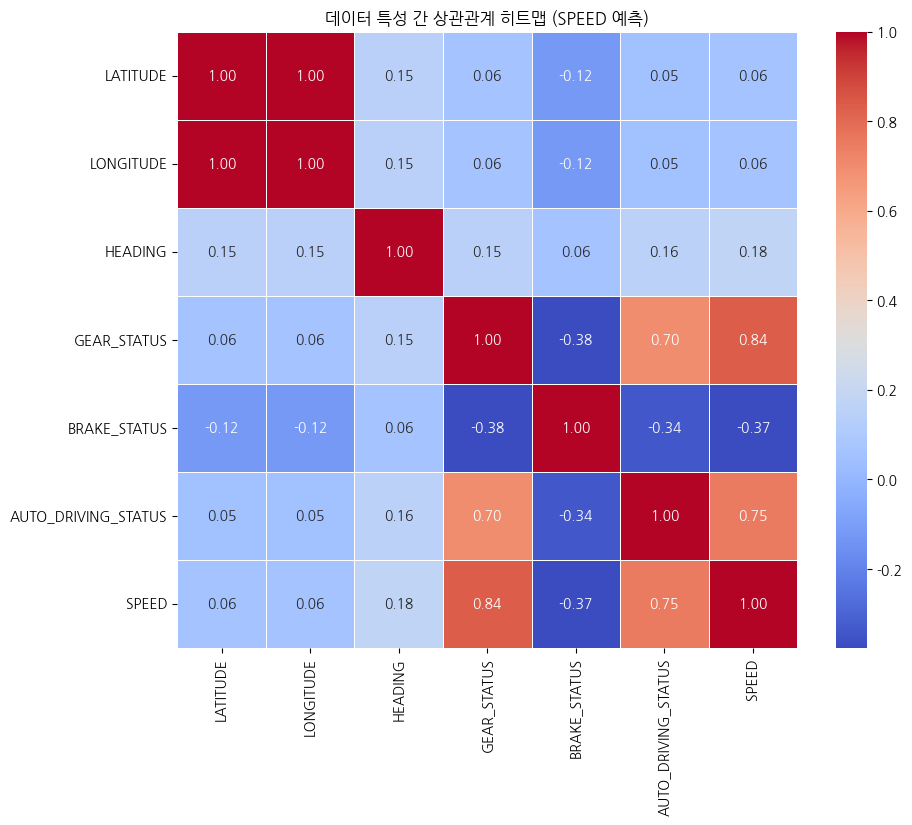

------------------------------
2. 데이터 전처리 중...
데이터 전처리 완료.
학습 데이터 샘플 수: 1349
테스트 데이터 샘플 수: 338
------------------------------
3. 딥러닝 모델 정의 중...
SimpleRegressionModel(
  (fc1): Linear(in_features=6, out_features=128, bias=True)
  (relu1): ReLU()
  (dropout1): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (relu2): ReLU()
  (dropout2): Dropout(p=0.2, inplace=False)
  (fc3): Linear(in_features=64, out_features=32, bias=True)
  (relu3): ReLU()
  (fc4): Linear(in_features=32, out_features=1, bias=True)
)
------------------------------
4. 모델 학습 시작...
Epoch [20/200], Loss: 0.1911
Epoch [40/200], Loss: 0.1860
Epoch [60/200], Loss: 0.1877
Epoch [80/200], Loss: 0.1821
Epoch [100/200], Loss: 0.1757
Epoch [120/200], Loss: 0.1722
Epoch [140/200], Loss: 0.1721
Epoch [160/200], Loss: 0.1733
Epoch [180/200], Loss: 0.1688
Epoch [200/200], Loss: 0.1673
모델 학습 완료.


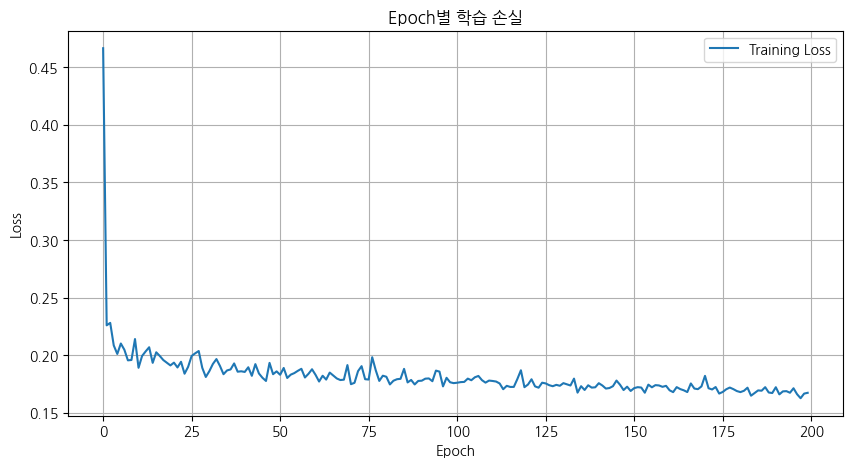

------------------------------
5. 예측 및 결과 시각화 중...


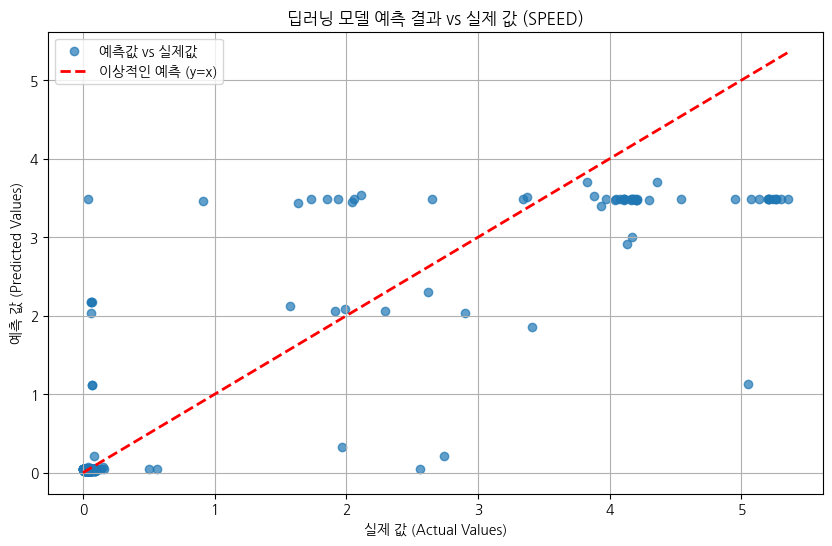

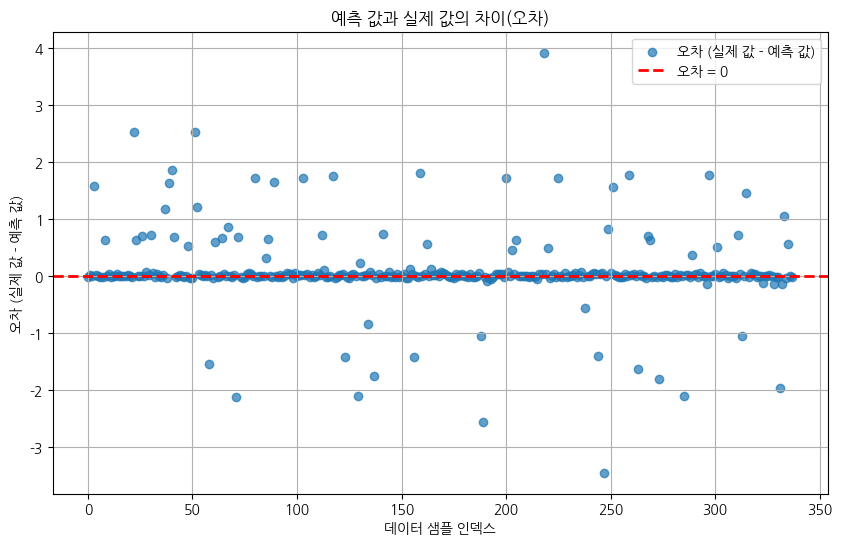

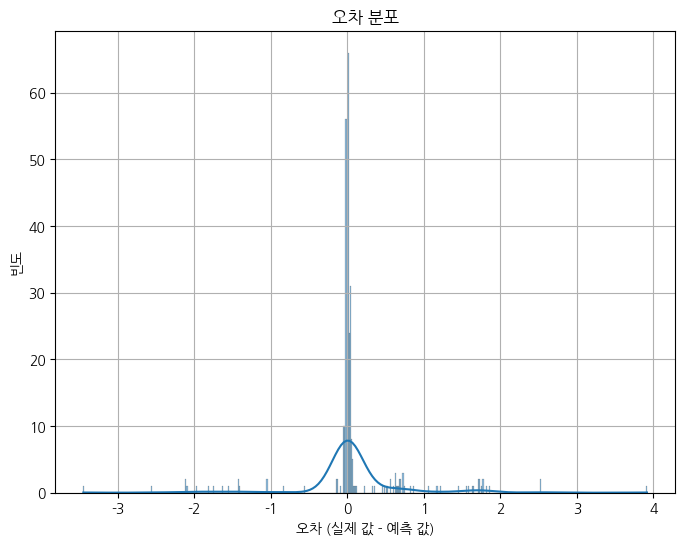

모든 과정 완료.


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#한글 폰트 설정 (Windows, Mac, Linux 환경에 맞게 주석 해제하여 사용)
#plt.rcParams['font.family'] = 'Malgun Gothic' # Windows
#plt.rcParams['font.family'] ='AppleGothic' # Mac
plt.rcParams['font.family'] ='NanumGothic' # Linux (나눔고딕 설치 필요)
plt.rcParams['axes.unicode_minus'] = False # 마이너스 부호 깨짐 방지

# 0. 실제 데이터 로드 및 기본 전처리
print("0. 실제 데이터 로드 및 기본 전처리 중...")
file_path = '/home/nmone/mk/python/kafka/egnode/test/data/mqtt/_VEHICLE_ING_INFO_TRAC.csv' # 사용자 파일 경로
try:
    data_df = pd.read_csv(file_path)
except FileNotFoundError:
    print(f"오류: 파일 '{file_path}'을(를) 찾을 수 없습니다. 경로를 확인해주세요.")
    exit()

print("원본 데이터 샘플:")
print(data_df.head())
print("\n데이터 정보:")
data_df.info()
print("\n데이터 기술 통계:")
print(data_df.describe())
print("-" * 30)

# 사용할 피처와 타겟 컬럼 정의
# V_TIMESTAMP, VEHICLE_ID, VEHICLE_TYPE, I_INDEX는 이 예제에서 제외
feature_columns = ['LATITUDE', 'LONGITUDE', 'HEADING', 'GEAR_STATUS', 'BRAKE_STATUS', 'AUTO_DRIVING_STATUS']
target_column = 'SPEED'

# 필요한 컬럼만 선택
selected_columns = feature_columns + [target_column]
data_for_model = data_df[selected_columns].copy()

# 결측치 확인 및 처리 (간단하게 결측치가 있는 행 제거)
print(f"\n선택된 컬럼 기준 결측치 확인 전 행 수: {len(data_for_model)}")
data_for_model.dropna(inplace=True)
print(f"결측치 제거 후 행 수: {len(data_for_model)}")

if len(data_for_model) == 0:
    print("오류: 데이터를 전처리한 후 남은 데이터가 없습니다. 원본 데이터를 확인해주세요.")
    exit()

print("\n모델 학습에 사용할 데이터 샘플:")
print(data_for_model.head())
print("-" * 30)


# 1. 데이터들 간의 상관관계 분석 및 시각화
print("1. 데이터 상관관계 분석 및 시각화 중...")
# 상관관계 분석을 위해 숫자형 데이터만 사용
correlation_matrix = data_for_model.corr()

plt.figure(figsize=(10, 8)) # 히트맵 크기 조정
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('데이터 특성 간 상관관계 히트맵 (SPEED 예측)')
plt.show()
print("-" * 30)

# 2. 데이터 전처리 (PyTorch 학습을 위해)
print("2. 데이터 전처리 중...")
X = data_for_model[feature_columns].values
y_target = data_for_model[target_column].values.reshape(-1, 1)

# 데이터가 충분한지 확인
if len(X) < 2 or len(y_target) < 2:
    print("오류: 학습 또는 테스트에 사용할 데이터가 충분하지 않습니다.")
    exit()
    
# test_size는 데이터 양에 따라 조절 가능
# 데이터가 매우 적을 경우 train_test_split이 오류를 발생시킬 수 있음
current_test_size = 0.2
if len(X) * current_test_size < 1: # 최소 1개의 테스트 샘플 확보
    current_test_size = 1 / len(X) if len(X) > 1 else 0
    if current_test_size == 0 and len(X) == 1: # 데이터가 1개뿐인 극단적 경우
         print("경고: 데이터 샘플이 1개뿐이어서 학습과 테스트 분할이 불가능합니다. 데모용으로만 진행합니다.")
         X_train, X_test, y_train, y_test = X, X, y_target, y_target # 임시방편
    else:
        print(f"경고: 테스트 데이터셋 크기가 너무 작아 {current_test_size}로 조정됩니다.")

if len(X) > 1 : # 데이터가 2개 이상일 때만 분할
    X_train, X_test, y_train, y_test = train_test_split(X, y_target, test_size=current_test_size, random_state=42)
else: # 데이터가 1개인 경우 (위에서 이미 처리했지만, 방어적으로)
    X_train, X_test, y_train, y_test = X, X, y_target, y_target


# 데이터 스케일링
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
if len(X_test) > 0:
    X_test_scaled = scaler_X.transform(X_test)
else:
    X_test_scaled = np.array([]) # 빈 배열로 초기화

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train)

# PyTorch Tensor로 변환
X_train_tensor = torch.FloatTensor(X_train_scaled)
y_train_tensor = torch.FloatTensor(y_train_scaled)
if len(X_test_scaled) > 0:
    X_test_tensor = torch.FloatTensor(X_test_scaled)
    y_test_tensor = torch.FloatTensor(y_test) # 원본 스케일의 y_test 유지
else: # 테스트셋이 없는 경우
    X_test_tensor = torch.FloatTensor([])
    y_test_tensor = torch.FloatTensor([])


# DataLoader 생성
# 배치 크기는 데이터셋 크기에 따라 조절
batch_size = min(16, len(X_train_tensor)) if len(X_train_tensor) > 0 else 1
if len(X_train_tensor) > 0:
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
else:
    print("오류: 학습 데이터가 없습니다.")
    exit()

print("데이터 전처리 완료.")
print(f"학습 데이터 샘플 수: {len(X_train_scaled)}")
print(f"테스트 데이터 샘플 수: {len(X_test_scaled)}")
print("-" * 30)

# 3. PyTorch를 사용한 딥러닝 모델 정의
print("3. 딥러닝 모델 정의 중...")
class SimpleRegressionModel(nn.Module):
    def __init__(self, input_size):
        super(SimpleRegressionModel, self).__init__()
        self.fc1 = nn.Linear(input_size, 128) # 레이어 노드 수 증가
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.2) # 드롭아웃 추가
        self.fc2 = nn.Linear(128, 64)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.2) # 드롭아웃 추가
        self.fc3 = nn.Linear(64, 32)
        self.relu3 = nn.ReLU()
        self.fc4 = nn.Linear(32, 1) # 출력 레이어

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.dropout1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.dropout2(x)
        x = self.fc3(x)
        x = self.relu3(x)
        x = self.fc4(x)
        return x

input_features = X_train_scaled.shape[1]
model = SimpleRegressionModel(input_features)
print(model)
print("-" * 30)

# 4. 모델 학습
print("4. 모델 학습 시작...")
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 200 # 에포크 수는 데이터와 모델에 따라 조절
train_losses = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    avg_epoch_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_epoch_loss)
    if (epoch + 1) % 20 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_epoch_loss:.4f}')

print("모델 학습 완료.")

# 학습 손실 그래프
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.title('Epoch별 학습 손실')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()
print("-" * 30)

# 5. 예측 및 결과 시각화
if len(X_test_tensor) > 0 and len(y_test_tensor) > 0:
    print("5. 예측 및 결과 시각화 중...")
    model.eval()
    with torch.no_grad():
        predictions_scaled = model(X_test_tensor)
        predictions = scaler_y.inverse_transform(predictions_scaled.numpy())

    actual_values = y_test_tensor.numpy()

    # 예측 결과와 실제 값 비교 시각화
    plt.figure(figsize=(10, 6))
    plt.scatter(actual_values, predictions, alpha=0.7, label='예측값 vs 실제값')
    min_val = min(actual_values.min(), predictions.min())
    max_val = max(actual_values.max(), predictions.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='이상적인 예측 (y=x)')
    plt.xlabel('실제 값 (Actual Values)')
    plt.ylabel('예측 값 (Predicted Values)')
    plt.title('딥러닝 모델 예측 결과 vs 실제 값 (SPEED)')
    plt.legend()
    plt.grid(True)
    plt.show()

    # 예측 값과 실제 값의 차이 (오차 또는 잔차) 시각화
    differences = actual_values - predictions

    plt.figure(figsize=(10, 6))
    # 데이터 포인트가 많을 경우 산점도 대신 라인 플롯이나 일부 샘플만 표시 고려
    if len(differences) > 1000: # 샘플이 너무 많으면 처음 1000개만 산점도로 표시
        plt.scatter(range(min(len(differences),1000)), differences[:min(len(differences),1000)], alpha=0.5, label='오차 (처음 1000개 샘플)')
    else:
        plt.scatter(range(len(differences)), differences, alpha=0.7, label='오차 (실제 값 - 예측 값)')
    plt.axhline(0, color='red', linestyle='--', lw=2, label='오차 = 0')
    plt.xlabel('데이터 샘플 인덱스')
    plt.ylabel('오차 (실제 값 - 예측 값)')
    plt.title('예측 값과 실제 값의 차이(오차)')
    plt.legend()
    plt.grid(True)
    plt.show()

    # 오차의 분포 시각화
    plt.figure(figsize=(8, 6))
    sns.histplot(differences.flatten(), kde=True) # .flatten() 추가하여 1D 배열로 만듦
    plt.xlabel('오차 (실제 값 - 예측 값)')
    plt.ylabel('빈도')
    plt.title('오차 분포')
    plt.grid(True)
    plt.show()
else:
    print("테스트 데이터가 없어 예측 및 시각화를 건너<0xEB><0x9B><0x81>니다.")

print("모든 과정 완료.")



0. 실제 데이터 로드 및 기본 전처리 중...
원본 데이터 샘플:
   I_INDEX  VEHICLE_ID VEHICLE_TYPE   LATITUDE   LONGITUDE  SPEED  \
0    14740  TRAC000001            T  36.466375  127.075636   0.03   
1    14741  TRAC000001            T  36.466375  127.075636   0.03   
2    14742  TRAC000001            T  36.466375  127.075636   0.04   
3    14743  TRAC000001            T  36.466375  127.075636   0.08   
4    14744  TRAC000001            T  36.466375  127.075636   0.05   

   AUTO_DRIVING_STATUS       V_TIMESTAMP  HEADING  GEAR_STATUS  BRAKE_STATUS  
0                    0  2025-05-22 14:42    93.66            0             0  
1                    0  2025-05-22 14:42    93.66            0             0  
2                    0  2025-05-22 14:42    93.65            0             0  
3                    0  2025-05-22 14:42    93.65            0             0  
4                    0  2025-05-22 14:42    93.66            0             0  

데이터 정보:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1687 entries, 